In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyref.fitting as fit
import seaborn as sns
import uncertainties.unumpy as unp
from matplotlib import gridspec, ticker
from matplotlib.patches import Patch
from scienceplots import scienceplots
from uncertainties import ufloat, umath

from utils import read_fit, read_ooc, read_xrr
from utils.helpers.plotting_helper import set_plotting_defaults

plt.style.use(["science", "no-latex"])
set_plotting_defaults()


In [4]:
dft_constrained = read_fit("dft/dft_en_offset_new2.pkl", material="znpc")
exp_constrained = read_fit("free/free_en_offset_init_2.pkl", material="znpc")


In [5]:
ooc = read_ooc("dft.csv", material="znpc")
# Zoom from 270 to 300 eV
ooc = ooc[ooc["energy"] > 270]
ooc = ooc[ooc["energy"] < 300]

def name_map(s: str):
    match s:
        case "znpc":
            return "bulk"
        case "contamination":
            return "interface"
        case _:
            return s

def as_ufloat(p):
    if p.stderr is None:
        return ufloat(p.value, 0)
    return ufloat(p.value, p.stderr)


def n(ooc_df, density, rotation):
    n_xx = unp.uarray(
        ooc_df["n_xx"].values,
        ooc_df["n_xx_err"].values if "n_xx_err" in ooc_df else np.zeros_like(ooc_df["n_xx"].values),
    )
    n_zz = unp.uarray(
        ooc_df["n_zz"].values,
        ooc_df["n_zz_err"].values if "n_zz_err" in ooc_df else np.zeros_like(ooc_df["n_zz"].values),
    )
    n_ixx = unp.uarray(
        ooc_df["n_ixx"].values,
        ooc_df["n_ixx_err"].values if "n_ixx_err" in ooc_df else np.zeros_like(ooc_df["n_ixx"].values),
    )
    n_izz = unp.uarray(
        ooc_df["n_izz"].values,
        ooc_df["n_izz_err"].values if "n_izz_err" in ooc_df else np.zeros_like(ooc_df["n_izz"].values),
    )

    c = umath.cos(rotation) ** 2
    s = umath.sin(rotation) ** 2
    n_o = ((n_xx * (c + 1) + n_zz * s) / 2) * density
    n_e = (n_xx * s + n_zz * c) * density
    n_io = ((n_ixx * (c + 1) + n_izz * s) / 2) * density
    n_ie = (n_ixx * s + n_izz * c) * density
    delta = 2 * n_o + n_e
    beta = 2 * n_io + n_ie
    dichroism = n_io - n_ie
    birefringence = n_o - n_e
    df = pd.DataFrame(
        {
            "energy": ooc_df["energy"].values,
            "n_o": unp.nominal_values(n_o),
            "n_o_err": unp.std_devs(n_o),
            "n_e": unp.nominal_values(n_e),
            "n_e_err": unp.std_devs(n_e),
            "n_io": unp.nominal_values(n_io),
            "n_io_err": unp.std_devs(n_io),
            "n_ie": unp.nominal_values(n_ie),
            "n_ie_err": unp.std_devs(n_ie),
            "delta": unp.nominal_values(delta),
            "delta_err": unp.std_devs(delta),
            "beta": unp.nominal_values(beta),
            "beta_err": unp.std_devs(beta),
            "dichroism": unp.nominal_values(dichroism),
            "dichroism_err": unp.std_devs(dichroism),
            "birefringence": unp.nominal_values(birefringence),
            "birefringence_err": unp.std_devs(birefringence),
        }
    )
    return df

def components(delta, biref):
    """
    Convert from (delta, birefringence) back to n_xx, n_zz.

    Here:
        delta        = 2*n_xx + n_zz
        biref        = n_xx - n_zz
    """
    n_xx = (delta + biref) / 3.0
    n_zz = (delta - 2.0 * biref) / 3.0
    return n_xx, n_zz

def extract_free_optical_parameters(objectives):
    params: dict[str, list] = {
        "slab": [],
        "energy": [],
        "delta": [],
        "delta_err": [],
        "beta": [],
        "beta_err": [],
        "dichroism": [],
        "dichroism_err": [],
        "birefringence": [],
        "birefringence_err": [],
        "xx": [],
        "xx_err": [],
        "zz": [],
        "zz_err": [],
        "ixx": [],
        "ixx_err": [],
        "izz": [],
        "izz_err": [],
    }

    for o in objectives:
        if o.model.energy == 250.0:
            continue
        structure = getattr(o.model.structure, "components", o.model.structure)
        for s in structure:
            if not hasattr(s, "sld") or isinstance(s.sld, fit.MaterialSLD):
                continue
            slab = name_map(s.name.split("_")[0].lower())
            xx = as_ufloat(s.sld.xx)
            zz = as_ufloat(s.sld.zz)
            ixx = as_ufloat(s.sld.ixx)
            izz = as_ufloat(s.sld.izz)
            delta = 2 * xx + zz
            beta = 2 * ixx + izz
            dich = ixx - izz
            biref = xx - zz
            params["slab"].append(slab)
            params["energy"].append(o.model.energy)
            params["delta"].append(delta.n)
            params["delta_err"].append(delta.s)
            params["beta"].append(beta.n)
            params["beta_err"].append(beta.s)
            params["dichroism"].append(dich.n)
            params["dichroism_err"].append(dich.s)
            params["birefringence"].append(biref.n)
            params["birefringence_err"].append(biref.s)
            params["xx"].append(xx.n)
            params["xx_err"].append(xx.s)
            params["zz"].append(zz.n)
            params["zz_err"].append(zz.s)
            params["ixx"].append(ixx.n)
            params["ixx_err"].append(ixx.s)
            params["izz"].append(izz.n)
            params["izz_err"].append(izz.s)

    return pd.DataFrame(params)

def extract_dft_optical_traces(dft_constrained, probe_energy, ooc):
    o = dft_constrained.objectives[
        np.where(np.array([o.model.energy for o in dft_constrained.objectives]) == probe_energy)[0][0]
    ]
    params = {
        "slab": [],
        "density": [],
        "rotation": [],
        "energy": [],
        "xx": [],
        "xx_err": [],
        "zz": [],
        "zz_err": [],
        "ixx": [],
        "ixx_err": [],
        "izz": [],
        "izz_err": [],
        "delta": [],
        "delta_err": [],
        "beta": [],
        "beta_err": [],
        "dichroism": [],
        "dichroism_err": [],
        "birefringence": [],
        "birefringence_err": [],
    }
    structure = getattr(o.model.structure, "components", o.model.structure)
    for s in (structure if hasattr(structure, "__iter__") and not isinstance(structure, str) else [structure]):
        if isinstance(s.sld, fit.UniTensorSLD):
            slab = name_map(s.name.split("_")[0].lower())
            density = as_ufloat(s.sld.density)
            rotation = as_ufloat(s.sld.rotation)
            index = n(
                ooc,
                density,
                rotation
            )
            params["slab"].extend([slab] * len(index))
            params["density"].extend([density] * len(index))
            params["rotation"].extend([rotation] * len(index))
            params["energy"].extend(ooc["energy"].copy())
            params["xx"].extend(index["n_o"])
            params["xx_err"].extend(index["n_o_err"])
            params["zz"].extend(index["n_e"])
            params["zz_err"].extend(index["n_e_err"])
            params["ixx"].extend(index["n_io"])
            params["ixx_err"].extend(index["n_io_err"])
            params["izz"].extend(index["n_ie"])
            params["izz_err"].extend(index["n_ie_err"])
            params["delta"].extend(index["delta"])
            params["delta_err"].extend(index["delta_err"])
            params["beta"].extend(index["beta"])
            params["beta_err"].extend(index["beta_err"])
            params["dichroism"].extend(index["dichroism"])
            params["dichroism_err"].extend(index["dichroism_err"])
            params["birefringence"].extend(index["birefringence"])
            params["birefringence_err"].extend(index["birefringence_err"])
    df = pd.DataFrame(params)
    # Sort by slab to be ordered "surface", "bulk", "interface"
    df = pd.concat(
        [df[df["slab"] == "surface"], df[df["slab"] == "bulk"], df[df["slab"] == "interface"]])
    return df


In [6]:
free_n = extract_free_optical_parameters(exp_constrained.objectives)
dft_n = extract_dft_optical_traces(dft_constrained, 283.7, ooc)

In [7]:
def plot_optical_components(df, components=("delta", "beta", "dichroism", "birefringence")):
    slabs = list(df["slab"].unique())
    n_slabs = len(slabs)
    if n_slabs == 0:
        return

    fig_width = 3.35
    fig_height = 1.5 * n_slabs
    fig, axs = plt.subplots(
        n_slabs,
        1,
        figsize=(fig_width, fig_height),
        sharex=True,
        dpi=300,
        gridspec_kw={"hspace": 0.05},
    )

    if n_slabs == 1:
        axs = [axs]

    palette = sns.color_palette()
    for i, slab in enumerate(slabs):
        data = df[df["slab"] == slab].sort_values("energy")
        ax = axs[i]

        for j, comp in enumerate(components):
            color = palette[j % len(palette)]
            y = data[comp].to_numpy()
            yerr = data[f"{comp}_err"].to_numpy()

            ax.errorbar(
                data["energy"],
                y,
                yerr=yerr,
                label=comp,
                color=color,
                marker="o",
                linestyle="None",
                markersize=1.5,
                ecolor=color,
                capsize=0.5,
                elinewidth=0.5,
                markeredgecolor="k",
                markerfacecolor=color,
                markeredgewidth=0.3,
            )

        ax.set_ylabel(slab)
        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

    axs[-1].set_xlabel("Energy (eV)")
    fig.align_labels()
    plt.show()

def plot_n_traces(
    dft_df,
    free_df,
    slabs=("surface", "bulk", "interface"),
    components=("xx", "zz")
)-> list[plt.Axes] | None:
    n_slabs = len(slabs)
    if n_slabs == 0:
        return

    fig_width = 3.35
    fig_height = 1.5 * n_slabs
    fig, axs = plt.subplots(
        n_slabs,
        1,
        figsize=(fig_width, fig_height),
        sharex=True,
        dpi=300,
        gridspec_kw={"hspace": 0.05},
    )

    if n_slabs == 1:
        axs = [axs]

    palette = sns.color_palette()
    for i, slab in enumerate(slabs):
        dft_slab = dft_df[dft_df["slab"] == slab].sort_values("energy")
        free_slab = free_df[free_df["slab"] == slab].sort_values("energy")
        ax = axs[i]

        for j, comp in enumerate(components):
            color = palette[j % len(palette)]
            err_col = f"{comp}_err"

            if comp in dft_slab.columns and err_col in dft_slab.columns:
                y_dft = dft_slab[comp].to_numpy()
                y_dft_err = dft_slab[err_col].to_numpy()
                ax.plot(
                    dft_slab["energy"],
                    y_dft, color=color, linewidth=1, label=comp)
                ax.fill_between(
                    dft_slab["energy"],
                    y_dft - y_dft_err,
                    y_dft + y_dft_err,
                    alpha=0.2,
                    color=color,
                )

            if comp in free_slab.columns and err_col in free_slab.columns:
                y_free = free_slab[comp].to_numpy()
                y_free_err = free_slab[err_col].to_numpy()
                ax.errorbar(
                    free_slab["energy"],
                    y_free,
                    yerr=y_free_err,
                    color=color,
                    marker="o",
                    linestyle="None",
                    markersize=1.5,
                    ecolor="k",
                    capsize=0.5,
                    elinewidth=0.5,
                )

        ax.set_ylabel(slab)
        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

    axs[-1].set_xlabel("Energy (eV)")
    fig.align_labels()
    return axs

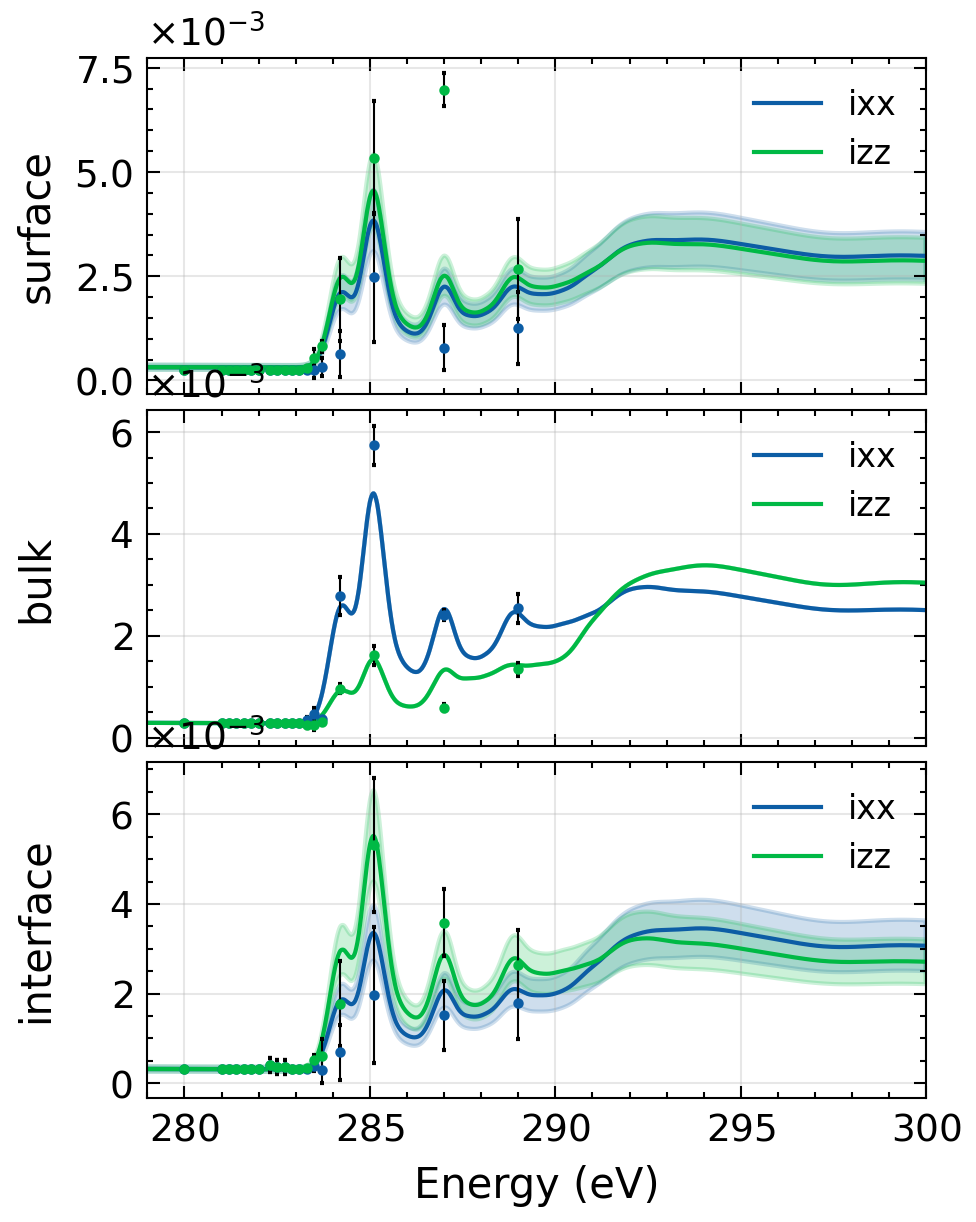

In [8]:
axs = plot_n_traces(
    dft_n,
    free_n,
    components=["ixx", "izz"]
)

for ax in axs:
    ax.legend()
    ax.set_xlim(279, 300)
plt.show()

In [9]:
from scipy.optimize import Bounds, minimize


# For each slab, fit the gamma tilt (rotation) and density from the free tensor components
def fit_orientation_from_free(free_slab, ooc_df, dft_slab, energy_col="energy", xx_col="xx", zz_col="zz", ixx_col="ixx", izz_col="izz", err_col_fmt="{col}_err"):
    """
    Fit the gamma tilt parameter (rotation, in radians) and density of the slab to the free ixx and izz tensor components.
    Returns the fitted rotation and density, as well as the optimization result.
    """

    # Model to calculate expected ixx and izz from tilt (gamma) and density.
    # Can adjust the physical model as appropriate.
    def model_components(gamma, density):
        """
        Computes the ixx, izz (rotated and density-scaled), as well as xx and zz (unrotated, not scaled) tensor components,
        for a given orientation (gamma, in radians) and density.
        Returns: ixx_model, izz_model, ixx_model, izz_model, xx, zz
        """
        enegies = free_slab[energy_col].to_numpy()
        # Interpolate the ooc_df to only contain these energies
        ixx = np.interp(enegies, ooc_df["energy"], ooc_df["n_ixx"])
        izz = np.interp(enegies, ooc_df["energy"], ooc_df["n_izz"])
        xx = np.interp(enegies, ooc_df["energy"], ooc_df["n_xx"])
        zz = np.interp(enegies, ooc_df["energy"], ooc_df["n_zz"])

        cos_gamma = np.cos(gamma)
        sin_gamma = np.sin(gamma)

        # Rotated and density-scaled components
        ixx_model = density * (ixx*(cos_gamma + 1) + izz * sin_gamma)/2
        xx_model = density * (xx*(cos_gamma + 1) + zz * sin_gamma)/2
        izz_model = density * (ixx * sin_gamma + izz * cos_gamma)
        zz_model = density * (xx * sin_gamma + zz * cos_gamma)

        return ixx_model, izz_model, xx_model, zz_model

    # Objective function for fitting
    def chi2(params):
        gamma, density = params
        ixx = free_slab[ixx_col].to_numpy()
        izz = free_slab[izz_col].to_numpy()
        ixx_err = free_slab.get(err_col_fmt.format(col='ixx'), np.ones_like(ixx))
        izz_err = free_slab.get(err_col_fmt.format(col='izz'), np.ones_like(izz))
        xx = free_slab[xx_col].to_numpy()
        zz = free_slab[zz_col].to_numpy()
        xx_err = free_slab.get(err_col_fmt.format(col='xx'), np.ones_like(xx))
        zz_err = free_slab.get(err_col_fmt.format(col='zz'), np.ones_like(zz))

        ixx_model, izz_model, xx_model, zz_model = model_components(gamma, density)
        chi2_val = np.sum(
            (ixx - ixx_model)**2 / ixx_err**2 +
            (izz - izz_model)**2 / izz_err**2 +
            (xx - xx_model)**2 / xx_err**2 +
            (zz - zz_model)**2 / zz_err**2
        )
        return chi2_val

    # get the initial guess from the dft_slab dataframe
    gamma = dft_slab["rotation"].values[0]
    density = dft_slab["density"].values[0]
    # Use the nominal values for x0
    x0 = [gamma.nominal_value, density.nominal_value]
    #use the uncertainties for the bounds
    bounds = Bounds(
        [min(0, gamma.nominal_value - 5*gamma.std_dev),
        max(0, density.nominal_value - density.std_dev)],
        [min(np.pi/2, gamma.nominal_value + 5*gamma.std_dev),
        max(0, density.nominal_value + density.std_dev)],
        keep_feasible=True
    )

    res = minimize(chi2, x0, bounds=bounds, method='L-BFGS-B')

    gamma_fit, density_fit = res.x
    return gamma_fit, density_fit, res

# Example usage for each slab in free tensor component DataFrame:
slab_results = {}
for slab in free_n["slab"].unique():
    slab_df = free_n[free_n["slab"] == slab]
    dft_slab = dft_n[dft_n["slab"] == slab]
    gamma, density, result = fit_orientation_from_free(slab_df, ooc, dft_slab)
    slab_results[slab] = {"gamma": gamma, "density": density, "result": result}


In [10]:
import numpy as np
from refnx.reflect.interface import Erf, Step


def slab_depth_profile(thickness, roughness, orientation, dz=0.01, kernel_bound=5):
    """
    Depth profile with error-function-smoothed steps at each internal boundary.

    Parameters
    ----------
    thickness : sequence of float
        Thickness of every slab in order
        ``| vacuum | material_1 | ... | material_m | substrate |``.
        The vacuum entry is overwritten: it is not a physical thickness; see Notes.
    roughness : sequence of float
        Same length as ``thickness``. For ``k >= 1``, ``roughness[k]`` is the sigma
        (Angstrom) between slab ``k-1`` and slab ``k``. ``roughness[0]`` is ignored
        (vacuum has no roughness; the air-to-first-material step uses ``roughness[1]``).
    orientation : sequence of float
        Orientation of each material slab only, length ``len(thickness) - 2``.
        Vacuum and substrate use ``baseline`` internally.
    dz : float, optional
        Depth sampling step (Angstrom).
    kernel_bound : int, optional
        Depth grid extends past the outermost interfaces by this multiple of the
        adjacent interface sigma (minimum ``dz`` when sigma is zero).

    Returns
    -------
    z : np.ndarray
        Depth (Angstrom). First material surface at ``z == 0``; vacuum has ``z < 0``.
    gamma : np.ndarray
        Orientation at each ``z``.

    Notes
    -----
    With ``S = len(thickness)``, slab indices are ``0`` vacuum, ``1..S-2`` materials,
    ``S-1`` substrate. Vacuum thickness is replaced by at least
    ``kernel_bound * max(roughness[1], dz)`` Angstrom so the first interface is resolved.
    After replacement, interface between slabs ``i`` and ``i+1`` is at
    ``z = sum(thickness[1:i+1])`` and uses sigma ``roughness[i+1]``.
    Smoothed steps use ``refnx.reflect.interface.Erf``; zero sigma uses ``Step``.
    """
    baseline = np.arcsin(np.sqrt(2 / 3))
    t = np.asarray(thickness, dtype=float).copy()
    rho = np.asarray(roughness, dtype=float)
    s = int(t.size)
    if s < 2:
        raise ValueError("thickness must include at least vacuum and substrate slabs")
    if rho.shape != (s,):
        raise ValueError("roughness must have the same length as thickness")
    n_material = s - 2
    if len(orientation) != n_material:
        raise ValueError(
            "orientation must have length len(thickness) - 2 (material slabs only)"
        )
    sigma_vm = max(float(rho[1]), float(dz))
    t[0] = max(kernel_bound * sigma_vm, float(dz))
    interface_z = np.empty(s - 1, dtype=float)
    interface_z[0] = 0.0
    for i in range(1, s - 1):
        interface_z[i] = interface_z[i - 1] + t[i]
    sigma_if = rho[1:s]
    z_min = min(-t[0], -kernel_bound * max(float(sigma_if[0]), float(dz)))
    tail_sig = max(float(sigma_if[-1]), float(dz))
    z_max = float(interface_z[-1] + t[-1]) + kernel_bound * tail_sig
    z = np.arange(z_min, z_max, dz)
    zone_orient = np.concatenate(
        ([baseline], np.asarray(orientation, dtype=float), [baseline])
    )
    gamma = np.full_like(z, zone_orient[0])
    erf_f = Erf()
    step_f = Step()
    for i in range(s - 1):
        loc = interface_z[i]
        sig = float(sigma_if[i])
        delta = zone_orient[i + 1] - zone_orient[i]
        f = step_f if sig == 0 else erf_f
        scale = 0.0 if sig == 0 else sig
        gamma += delta * f(z, scale=scale, loc=loc)
    return z, gamma

In [11]:
thicknesses = [
    s.thick.value for s in exp_constrained.objectives[0].model.structure
]
roughnesses = [
    s.rough.value for s in exp_constrained.objectives[0].model.structure
]
orientations = [
    res["gamma"] for res in slab_results.values()
] + [np.arcsin(np.sqrt(2 / 3))]

print(len(orientations), len(roughnesses), len(thicknesses))

4 6 6


In [12]:
thicknesses_dft = [
    s.thick.value for s in dft_constrained.objectives[0].model.structure
]
roughnesses_dft = [
    s.rough.value for s in dft_constrained.objectives[0].model.structure
]
orientations_dft = [*[s.sld.rotation.value for s in dft_constrained.objectives[0].model.structure][1:-2], np.arcsin(np.sqrt(2 / 3))]

print(len(orientations_dft), len(roughnesses_dft), len(thicknesses_dft))

4 6 6


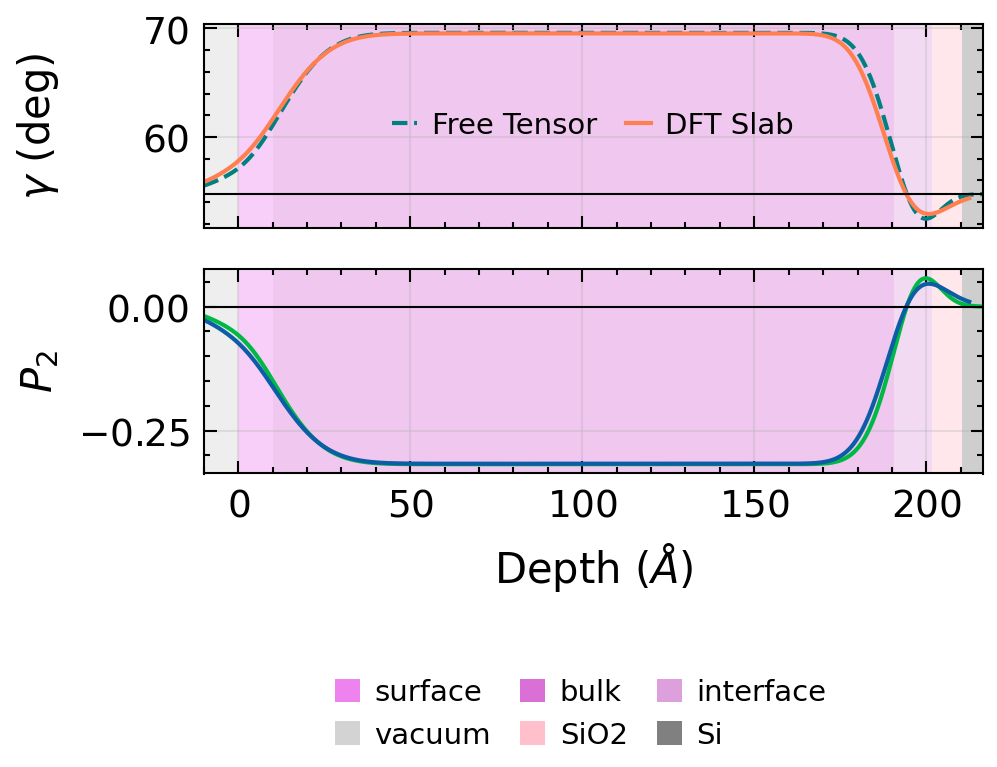

In [13]:
from matplotlib.patches import Patch

z, gamma = slab_depth_profile(
    thicknesses,
    roughnesses,
    orientations,
)
gamma_deg = gamma * 180 / np.pi
z_dft, gamma_dft = slab_depth_profile(
    thicknesses_dft,
    roughnesses_dft,
    orientations_dft,
)
gamma_dft_deg = gamma_dft * 180 / np.pi

def order_parameter(gamma):
    return (3 / 2) * (np.cos(gamma) ** 2 - 1 / 3)

p2 = order_parameter(gamma)
p2_dft = order_parameter(gamma_dft)

region_labels = ["vacuum", "surface", "bulk", "interface", "SiO2", "Si"]
region_colors = ["lightgray", "violet", "orchid", "plum", "pink", "grey"]
cum_phys = np.cumsum(np.asarray(thicknesses[1:], dtype=float))
region_edges = [float(z[0]), 0.0] + cum_phys.tolist()
region_edges[-1] = max(region_edges[-1], float(z[-1]))

fig_width = 3.35
fig_height = 2.5
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(fig_width, fig_height),
    dpi=300,
    gridspec_kw={"hspace": 0.2},
)
for ax in (ax1, ax2):
    for j, color in enumerate(region_colors):
        ax.axvspan(
            region_edges[j],
            region_edges[j + 1],
            facecolor=color,
            edgecolor="none",
            alpha=0.38,
            zorder=0,
        )

ax1.plot(z, gamma_deg, color="teal", zorder=2, label="Free Tensor",
    ls="--"
)
ax1.plot(
    z_dft, gamma_dft_deg, color="coral", zorder=2, label="DFT Slab",
    ls="-",
)

ax1.axhline(
    np.arcsin(np.sqrt(2 / 3)) * 180 / np.pi,
    color="k",
    linestyle="-",
    linewidth=plt.rcParams["axes.linewidth"],
    zorder=3,
)
ax2.set_xlabel(r"Depth ($\AA$)")
ax1.set_ylabel(r"$\gamma$ (deg)")

ax2.plot(z, p2, color="C1", zorder=2, label="Free Tensor")
ax2.plot(z_dft, p2_dft, color="C0", zorder=2, label="DFT Slab")
ax2.axhline(
    0,
    color="k",
    linestyle="-",
    linewidth=plt.rcParams["axes.linewidth"],
    zorder=3,
)
ax2.set_ylabel(r"$P_2$")
ax2.set_xlim(-10, z.max())
# ax2.set_ylim(-0.5, .25)
# ax1.set_ylim(50, 75)
fig.align_ylabels([ax1, ax2])

ax1.legend(loc="center", ncol=2, frameon=False, handlelength=0.85, handleheight=0.85, columnspacing=1, handletextpad=0.5, borderpad=0.1, fontsize=7)

# Reorder the regions to surface, bulk, interface, vacuum, sio2, Si
region_order = ["surface", "vacuum", "bulk", "SiO2", "interface", "Si"]
region_label_to_color = dict(zip(region_labels, region_colors))
region_handles = [
    Patch(facecolor=region_label_to_color[lab], linewidth=0.4, label=lab)
    for lab in region_order
]
leg = fig.legend(
    handles=region_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=3,
    frameon=False,
    handlelength=0.85,
    handleheight=0.85,
    columnspacing=1,
    handletextpad=0.5,
    borderpad=0.1,
    fontsize=7,
)
leg.set_in_layout(True)
fig.subplots_adjust(bottom=0.28)

In [14]:
# save the orientation profiles as csv files
df_free = pd.DataFrame({"z": z, "gamma": gamma})
df_dft = pd.DataFrame({"z": z_dft, "gamma": gamma_dft})
df_free.to_csv("free_tensor_orientation.csv", index=False)
df_dft.to_csv("dft_slab_orientation.csv", index=False)

In [17]:
import colorsys


def shade_layers_p2_mapped(ax, z_profile, p2_profile, region_edges, region_labels, LAYER_CFG):
    """
    Signed P₂ color mapping over the full orientation profile.

    Encoding
    --------
    P₂ < 0  (face-on)   →  purple,  saturation ∝ |P₂|
    P₂ > 0  (edge-on)   →  amber,   saturation ∝ |P₂|
    P₂ = 0  (isotropic) →  pure gray (saturation = 0, guaranteed)

    Boundaries
    ----------
    - Surface side (z < film_start): alpha fades linearly to 0 so the fill
      dissolves into the white vacuum background.
    - Substrate side (z > film_end): alpha is held at ALPHA_BASE so the fill
      meets the SiO2/Si region with a hard edge.

    Flat fills for vacuum, SiO2, and Si are drawn from LAYER_CFG as before.
    """
    import matplotlib.colors as mcolors

    HUE_FACE_ON = 0.78    # purple — flat-lying / face-on
    HUE_EDGE_ON = 0.08    # amber  — upright / edge-on
    LIGHTNESS   = 0.68    # fixed; lower = richer color at full saturation
    P2_MAX      = p2_profile.max()
    P2_MIN      = p2_profile.min()
    MAX_SAT     = 0.90    # maximum achievable saturation
    ALPHA_BASE  = 0.72    # alpha inside and at the substrate edge

    # Film boundaries from the slab structure
    film_start = region_edges[1]    # vacuum → film
    film_end   = region_edges[-2]   # film → SiO2

    # Fade zone: distance over which alpha ramps from 0 → ALPHA_BASE
    # on the vacuum side.  Use the surface roughness scale (~10 Å typical).
    FADE_WIDTH = 15.0   # Å — adjust to match your surface roughness

    # ── Build per-sample RGBA ────────────────────────────────────────────────

    rgba = np.zeros((len(z_profile), 4))

    for i, (z_val, p2_val) in enumerate(zip(z_profile, p2_profile)):
        # Saturation: strictly zero when P₂ == 0 by construction
        if p2_val <= 0.0:
            # Face-on branch: normalize against the negative extreme
            sat = np.clip(p2_val / P2_MIN, 0.0, 1.0) * MAX_SAT
            hue = HUE_FACE_ON
        else:
            # Edge-on branch: normalize against the positive extreme
            sat = np.clip(p2_val / P2_MAX, 0.0, 1.0) * MAX_SAT
            hue = HUE_EDGE_ON

        # At sat == 0, hls_to_rgb returns a gray regardless of hue — correct.
        rgb = colorsys.hls_to_rgb(hue, LIGHTNESS, sat)

        # Alpha: fade to transparent on the vacuum side of film_start,
        # hold flat everywhere else (including inside substrate region).
        if z_val < film_start:
            # Linear ramp: 0 at (film_start - FADE_WIDTH), ALPHA_BASE at film_start
            t = (z_val - (film_start - FADE_WIDTH)) / FADE_WIDTH
            alpha = float(np.clip(t, 0.0, 1.0)) * ALPHA_BASE
        else:
            alpha = ALPHA_BASE

        rgba[i] = (*rgb, alpha)

    # ── Draw as pcolormesh ───────────────────────────────────────────────────
    # Set ylim before calling this function so the mesh spans the axes correctly.

    y_lo, y_hi = ax.get_ylim()
    z_edges = np.concatenate(
        [[z_profile[0]],
         0.5 * (z_profile[:-1] + z_profile[1:]),
         [z_profile[-1]]]
    )
    mesh_y     = np.array([y_lo, y_hi])
    color_grid = rgba[np.newaxis, :, :]   # shape (1, N, 4)

    ax.pcolormesh(
        z_edges, mesh_y, color_grid,
        shading="flat",
        zorder=0,
        rasterized=True,    # avoids hairline gaps and large vector PDFs
    )

    # ── Flat fills for isotropic substrate / vacuum regions ─────────────────

    iso_labels = ("vacuum", "SiO2", "Si")
    for j, label in enumerate(region_labels):
        if label not in iso_labels:
            continue
        fc, alpha = LAYER_CFG[label]
        ax.axvspan(
            region_edges[j], region_edges[j + 1],
            facecolor=fc, edgecolor="none", alpha=alpha, zorder=0,
        )

    # ── Boundary marker lines ────────────────────────────────────────────────

    for xv in (region_edges[1], region_edges[-2]):
        ax.axvline(xv, color="0.50", lw=0.5, ls=":", zorder=1)

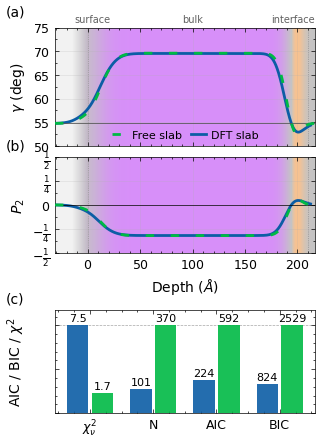

In [18]:
"""
Three-panel PRL figure (3.35 in wide):
  (a)  γ vs depth
  (b)  P₂ vs depth
  (c)  AIC / BIC / χ² comparison — grouped bar chart

Color convention
  DFT slab    →  #5DA5DA  (sky blue),    solid line
  Free tensor →  #FAA43A  (warm orange), dashed line

Drop-in points
  Populate thicknesses / roughnesses / orientations (and _dft variants)
  from your model objects before running.  Everything else is
  self-contained.
"""


# ── Helpers ──────────────────────────────────────────────────────────────────

def slab_depth_profile(thickness, roughness, orientation, dz=0.01, kernel_bound=5):
    baseline = np.arcsin(np.sqrt(2 / 3))
    t   = np.asarray(thickness,   dtype=float).copy()
    rho = np.asarray(roughness,   dtype=float)
    s   = int(t.size)
    sigma_vm = max(float(rho[1]), float(dz))
    t[0] = max(kernel_bound * sigma_vm, float(dz))
    interface_z    = np.empty(s - 1, dtype=float)
    interface_z[0] = 0.0
    for i in range(1, s - 1):
        interface_z[i] = interface_z[i - 1] + t[i]
    sigma_if = rho[1:s]
    z_min    = min(-t[0], -kernel_bound * max(float(sigma_if[0]), float(dz)))
    tail_sig = max(float(sigma_if[-1]), float(dz))
    z_max    = float(interface_z[-1] + t[-1]) + kernel_bound * tail_sig
    z = np.arange(z_min, z_max, dz)
    zone_orient = np.concatenate(
        ([baseline], np.asarray(orientation, dtype=float), [baseline])
    )
    gamma  = np.full_like(z, zone_orient[0])
    erf_f  = Erf()
    step_f = Step()
    for i in range(s - 1):
        loc   = interface_z[i]
        sig   = float(sigma_if[i])
        delta = zone_orient[i + 1] - zone_orient[i]
        f     = step_f if sig == 0 else erf_f
        scale = 0.0    if sig == 0 else sig
        gamma += delta * f(z, scale=scale, loc=loc)
    return z, gamma


def order_parameter(gamma):
    return (3 / 2) * (np.cos(gamma) ** 2 - 1 / 3)

# ── Color palette ─────────────────────────────────────────────────────────────

PALETTE = [
    "C0",   # 0  sky blue    — DFT slab  (primary)
    "C1",   # 1  orange      — free tensor (comparison)
    "C2",   # 2  green
    "C3",   # 3  pink
    "C4",   # 4  purple
    "C5",   # 5  yellow
]

C_DFT  = PALETTE[0]
C_FREE = PALETTE[1]

# Layer shading: single blue-gray hue, opacity encodes structural sub-layer.
# Substrate and vacuum use a neutral gray.
LAYER_CFG = {
    "vacuum":    ("#9B9B9B", 0.12),
    "surface":   ("#C4B8C8", 0.35),
    "bulk":      ("#C4B8C8", 0.60),
    "interface": ("#C4B8C8", 0.35),
    "SiO2":      ("#8A8A8A", 0.0),   # neutral gray SiO2 layer
    "Si":        ("#8A8A8A", 0.0),   # neutral gray substrate
}
# configure dashes to have extra white space between the dashes
dashes = (3, 6)

MAGIC_ANGLE_DEG = np.arcsin(np.sqrt(2 / 3)) * 180 / np.pi   # ≈ 54.74°

# ── Data — replace with your real objects ────────────────────────────────────

z,     gamma     = slab_depth_profile(thicknesses,     roughnesses,     orientations)
z_dft, gamma_dft = slab_depth_profile(thicknesses_dft, roughnesses_dft, orientations_dft)

gamma_deg     = gamma     * 180 / np.pi
gamma_dft_deg = gamma_dft * 180 / np.pi
p2            = order_parameter(gamma)
p2_dft        = order_parameter(gamma_dft)

# ── Region geometry (derived from free-tensor slab structure) ─────────────────

region_labels = ["vacuum", "surface", "bulk", "interface", "SiO2", "Si"]
cum_phys      = np.cumsum(np.asarray(thicknesses[1:], dtype=float))
region_edges  = [float(z[0]), 0.0] + cum_phys.tolist()
region_edges[-1] = max(region_edges[-1], float(z[-1]))

# ── Statistics ────────────────────────────────────────────────────────────────

stats = {
    "DFT slab":    {
        "chi2": 7.5,
        "aic": 223.8,
        "bic":  824.3,
        "N": len(dft_constrained.varying_parameters())
        },
    "Free tensor": {
        "chi2": 1.7,
        "aic": 591.6,
        "bic": 2529.1,
        "N": len(exp_constrained.varying_parameters())
        },
}

# ── Figure layout ─────────────────────────────────────────────────────────────

FIG_W = 3.35
FIG_H = 4.70   # extra height accommodates layer labels above (a) and bar
               # annotations above (c) without clipping

fig = plt.figure(figsize=(FIG_W, FIG_H))

gs_profiles = gridspec.GridSpec(
    2, 1,
    figure=fig,
    height_ratios=[1.10, 0.90],
    hspace=0.1,
    top=0.90,
    bottom=0.42,          # raised from 0.38 → wider gap below (b)
)

gs_stat = gridspec.GridSpec(
    1, 1,
    figure=fig,
    top=0.30,             # unchanged — (c) keeps its position
    bottom=0.08,
)

ax_gamma = fig.add_subplot(gs_profiles[0])
ax_p2    = fig.add_subplot(gs_profiles[1], sharex=ax_gamma)
ax_stat  = fig.add_subplot(gs_stat[0])

# ── Layer shading helper ──────────────────────────────────────────────────────

def shade_layers(ax):
    for j, label in enumerate(region_labels):
        fc, alpha = LAYER_CFG[label]
        ax.axvspan(
            region_edges[j], region_edges[j + 1],
            facecolor=fc, edgecolor="none", alpha=alpha, zorder=0,
        )
    # subtle dotted boundary lines at the vacuum|film and film|substrate edges
    for xv in (region_edges[1], region_edges[-2]):
        ax.axvline(xv, color="0.50", lw=0.5, ls=":", zorder=1)

# ── Panel (a): γ vs depth ─────────────────────────────────────────────────────


ax_gamma.plot(z,     gamma_deg,     color=C_FREE, ls="--", lw=2,
              zorder=3, label="Free slab", dashes=dashes)
ax_gamma.plot(z_dft, gamma_dft_deg, color=C_DFT,  ls="-",  lw=2,
              zorder=2, label="DFT slab")
ax_gamma.axhline(MAGIC_ANGLE_DEG, color="0.35", lw=0.6, ls="-", zorder=2)

ax_gamma.set_ylabel(r"$\gamma$ (deg)")
ax_gamma.set_xlim(region_edges[0], z.max())
ax_gamma.set_ylim(50, 75)
shade_layers_p2_mapped(ax_gamma, z, p2, region_edges, region_labels, LAYER_CFG)
ax_gamma.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax_gamma.yaxis.set_minor_locator(ticker.MultipleLocator(2.5))
ax_gamma.tick_params(labelbottom=False)

ax_gamma.legend(
    loc="lower center",
    ncol=2,
    handlelength=1.4,
    handleheight=0.8,
    columnspacing=0.8,
    handletextpad=0.4,
    borderpad=0.0,
    frameon=False,
)

# Layer name annotations — placed in a blended transform so x tracks data
# coordinates and y sits above the top spine in axes-fraction space.
# va="bottom" + y > 1.0 pushes them into the top margin set by gs(top=0.90).
anno_tf = mpl.transforms.blended_transform_factory(
    ax_gamma.transData, ax_gamma.transAxes
)
layer_anno = [
    ("surface",   (region_edges[1] + region_edges[2]) / 2),
    ("bulk",      (region_edges[2] + region_edges[3]) / 2),
    ("interface", (region_edges[3] + region_edges[4]) / 2),
]
for lbl, xc in layer_anno:
    ax_gamma.text(
        xc, 1.03, lbl,
        transform=anno_tf,
        ha="center", va="bottom",
        fontsize=7, color="0.38",
        clip_on=False,
    )

# Panel label sits outside the axes box, above the layer annotations
ax_gamma.text(
    -0.19, 1.08, "(a)",
    transform=ax_gamma.transAxes,
    va="bottom", fontsize=10,
)

# ── Panel (b): P₂ vs depth ───────────────────────────────────────────────────

# shade_layers(ax_p2)

ax_p2.plot(z,     p2,     color=C_FREE, ls="--", lw=2, zorder=3, dashes=dashes)
ax_p2.plot(z_dft, p2_dft, color=C_DFT,  ls="-",  lw=2, zorder=2)
ax_p2.axhline(0, color=plt.rcParams["axes.edgecolor"], lw=plt.rcParams["axes.linewidth"], ls="-", zorder=2)
ax_p2.set_ylabel(r"$P_2$")
ax_p2.set_xlabel(r"Depth ($\AA$)")
ax_p2.set_xlim(region_edges[0], z.max())
ax_p2.set_ylim(-0.5, 0.5)
shade_layers_p2_mapped(ax_p2, z, p2, region_edges, region_labels, LAYER_CFG)
ax_p2.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
ax_p2.yaxis.set_minor_locator(ticker.MultipleLocator(0.125))
ax_p2.set_yticks([-0.5, -0.25, 0, 0.25, 0.5])
ax_p2.set_yticklabels([r"$-\frac{1}{2}$", r"$-\frac{1}{4}$", r"$0$", r"$\frac{1}{4}$", r"$\frac{1}{2}$"])

ax_p2.text(
    -0.19, 1.04, "(b)",
    transform=ax_p2.transAxes,
    va="bottom", fontsize=10,
)

# ── Panel (c): statistics bar chart ──────────────────────────────────────────
#
# Each metric is normalised to its own maximum so χ², AIC and BIC (which span
# three orders of magnitude) all fit on one clean axis. Raw values are
# annotated above each bar.

METRICS     = [r"$\chi^2_\nu$", "N", "AIC", "BIC"]
BAR_W       = 0.28
GROUP_GAP   = 0.82
INTRA_GAP   = 0.04

models     = list(stats.keys())
bar_colors = [C_DFT, C_FREE]
mkeys      = ["chi2", "N", "aic", "bic"]

gcentres = np.arange(len(METRICS)) * GROUP_GAP
offsets = np.linspace(
    -((len(models) - 1) * (BAR_W + INTRA_GAP) / 2),
    ((len(models) - 1) * (BAR_W + INTRA_GAP) / 2),
    len(models)
)

raw_vals = {mk: np.array([stats[m][mk] for m in models]) for mk in mkeys}
norms    = {mk: v.max() for mk, v in raw_vals.items()}

# First pass: find the tallest annotation to set ylim headroom
max_norm_annotated = 1.0   # the tallest bar is always 1.0

for gi, mk in enumerate(mkeys):
    for bi, (model, color) in enumerate(zip(models, bar_colors)):
        raw  = stats[model][mk]
        norm = raw / norms[mk]
        x    = gcentres[gi] + offsets[bi]

        ax_stat.bar(
            x, norm,
            width=BAR_W,
            color=color,
            alpha=0.90,
            linewidth=0,
            zorder=2,
        )

        fmt = f"{raw:.1f}" if mk == "chi2" else f"{raw:.0f}"
        ax_stat.text(
            x, norm + 0.025,
            fmt,
            ha="center", va="bottom",
            fontsize=8
        )

# ylim: 1.0 (max bar) + room for the tallest annotation string + small pad.
# At fontsize 8 in a ~1.0-inch-tall axes, one line ≈ 0.13 normalised units.
ax_stat.set_ylim(0, 1.18)

ax_stat.set_xticks(gcentres)
ax_stat.set_xticklabels(METRICS)
# ax_stat.set_xlim(gcentres[0] - GROUP_GAP * 0.58,
#                  gcentres[-1] + GROUP_GAP * 0.58)

# # Hide y-axis and three spines; keep only the bottom spine as a baseline.
# ax_stat.yaxis.set_visible(False)
# ax_stat.spines["left"].set_visible(False)
# ax_stat.spines["right"].set_visible(False)
# ax_stat.spines["top"].set_visible(False)
# ax_stat.tick_params(axis="x", direction="out", bottom=True, top=False,
#                     labelsize=9)
# Hide y-axis tick labels and axis label
ax_stat.set_yticklabels([])
ax_stat.set_ylabel("")

# The house rcParams enables axes.grid globally; turn it off here because the
# y-axis is hidden and grid lines on a bar chart with no y ticks are noise.
ax_stat.grid(False)

# Dashed reference line at normalised maximum
ax_stat.axhline(1.0, color="0.65", lw=0.5, ls="--", zorder=1)

# Model legend — patch swatches, no frame (set globally)
# ax_stat.legend(
#     handles=[
#         Patch(facecolor=C_DFT,  alpha=0.90, label="DFT slab"),
#         Patch(facecolor=C_FREE, alpha=0.90, label="Free tensor"),
#     ],
#     loc="upper left",
#     ncol=1,
#     handlelength=0.9,
#     handleheight=0.80,
#     handletextpad=0.5,
#     borderpad=0.0,
#     fontsize=8,
# )

ax_stat.set_ylabel(r"AIC / BIC / $\chi^2$")

ax_stat.text(
    -0.19, 1.04, "(c)",
    transform=ax_stat.transAxes,
    va="bottom", fontsize=10,
)

# ── Final alignment and export ────────────────────────────────────────────────

fig.align_ylabels([ax_gamma, ax_p2, ax_stat])

plt.savefig(
    "orientation_profiles.png", format="png", dpi=300,
    bbox_inches="tight", transparent=True
)

plt.show()

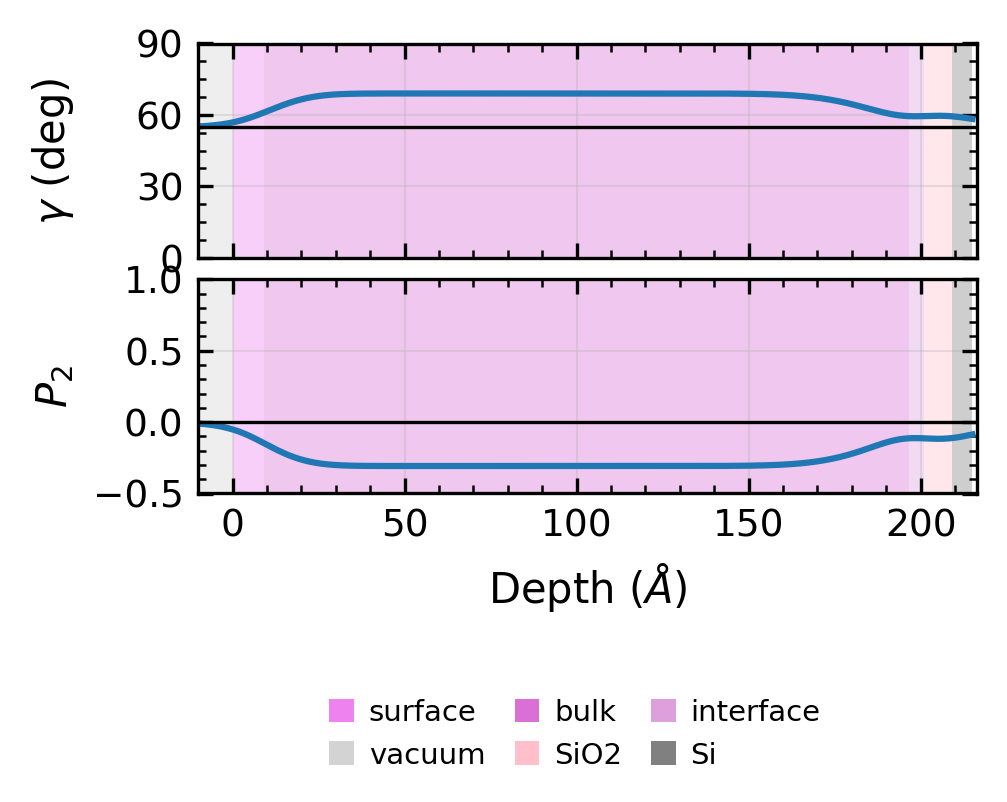

In [75]:
from matplotlib.patches import Patch

z, gamma = slab_depth_profile(
    thicknesses,
    roughnesses,
    orientations,
)
gamma_deg = gamma * 180 / np.pi
z_dft, gamma_dft = slab_depth_profile(
    thicknesses_dft,
    roughnesses_dft,
    orientations_dft,
)
gamma_dft_deg = gamma_dft * 180 / np.pi

def order_parameter(gamma):
    return (3 / 2) * (np.cos(gamma) ** 2 - 1 / 3)

p2 = order_parameter(gamma)
p2_dft = order_parameter(gamma_dft)

region_labels = ["vacuum", "surface", "bulk", "interface", "SiO2", "Si"]
region_colors = ["lightgray", "violet", "orchid", "plum", "pink", "grey"]
cum_phys = np.cumsum(np.asarray(thicknesses_dft[1:], dtype=float))
region_edges = [float(z_dft[0]), 0.0] + cum_phys.tolist()
region_edges[-1] = max(region_edges[-1], float(z_dft[-1]))

fig_width = 3.35
fig_height = 2.5
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(fig_width, fig_height),
    dpi=300,
    gridspec_kw={"hspace": 0.1},
)
for ax in (ax1, ax2):
    for j, color in enumerate(region_colors):
        ax.axvspan(
            region_edges[j],
            region_edges[j + 1],
            facecolor=color,
            edgecolor="none",
            alpha=0.38,
            zorder=0,
        )
ax1.plot(z_dft, gamma_dft_deg, color="C0", zorder=2, label="DFT Slab")
# ax1.plot(z, gamma_deg, color="C1", zorder=2, label="Free Tensor")
ax1.axhline(
    np.arcsin(np.sqrt(2 / 3)) * 180 / np.pi,
    color="k",
    linestyle="-",
    linewidth=plt.rcParams["axes.linewidth"],
    zorder=3,
)
ax2.set_xlabel(r"Depth ($\AA$)")
ax1.set_ylabel(r"$\gamma$ (deg)")
ax1.set_ylim(0, 90)
# ax2.plot(z, p2, color="C1", zorder=2, label="Free Tensor")
ax2.plot(z_dft, p2_dft, color="C0", zorder=2, label="DFT Slab")
ax2.axhline(
    0,
    color="k",
    linestyle="-",
    linewidth=plt.rcParams["axes.linewidth"],
    zorder=3,
)
ax2.set_ylabel(r"$P_2$")
ax2.set_xlim(-10, z.max())
ax2.set_ylim(-0.5, 1)
ax2.set_yticks([-0.5, 0, 0.5, 1])
ax1.set_yticks([0, 30, 60, 90])
fig.align_ylabels([ax1, ax2])

# Reorder the regions to surface, bulk, interface, vacuum, sio2, Si
region_order = ["surface", "vacuum", "bulk", "SiO2", "interface", "Si"]
region_label_to_color = dict(zip(region_labels, region_colors))
region_handles = [
    Patch(facecolor=region_label_to_color[lab], linewidth=0.4, label=lab)
    for lab in region_order
]
leg = fig.legend(
    handles=region_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=3,
    frameon=False,
    handlelength=0.85,
    handleheight=0.85,
    columnspacing=1,
    handletextpad=0.5,
    borderpad=0.1,
    fontsize=7,
)
leg.set_in_layout(True)
fig.subplots_adjust(bottom=0.28)

In [47]:
# plot on top of eachother

In [48]:
display(dft_n[dft_n["slab"] == "surface"]["rotation"].values[0] * 180 / np.pi)
display(dft_n[dft_n["slab"] == "bulk"]["rotation"].values[0] * 180 / np.pi)
display(dft_n[dft_n["slab"] == "interface"]["rotation"].values[0] * 180 / np.pi)

52.20775813673763+/-0.007251971814206034

69.5386131909103+/-0.011329957299174439

47.24147373201817+/-0.008667240433702419

In [ ]:
# Find the energy between 275 and 300 eV where the birenfringence changes sign in the
# intefrace slab

slab_n = dft_n[dft_n["slab"] == "interface"]
sign_change = np.sign(slab_n["birefringence"])
sign_change

In [ ]:
dft_constrained.objectives[16].model.structure.plot()

In [ ]:
exp_constrained.objectives[16].model.structure.plot()

In [ ]:

#  extract orientation from dft_constrained system
rotations = {"contamination": 0.0, "bulk": 0.0, "interface": 0.0}
density = {"contamination": 0.0, "bulk": 0.0, "interface": 0.0}
comparison_energies = np.array([250.0, 283.7])
exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
o = dft_objectives[283.7]
rotations["contamination"] = o.model.structure[1].sld.rotation
rotations["bulk"] = o.model.structure[2].sld.rotation
rotations["interface"] = o.model.structure[3].sld.rotation
density["contamination"] = o.model.structure[1].sld.density
density["bulk"] = o.model.structure[2].sld.density
density["interface"] = o.model.structure[3].sld.density

# Extract the imaginary components and their errors from the exp_constrained dataset
def optical_constants(model):
    oc = {}
    names = ["contamination", "bulk", "interface"]
    for i, s in enumerate(model.structure):
        if isinstance(s.sld, fit.UniTensorSLD):
            print(s)
            break
        if i in [0, 4,5]:
            continue
        n_ixx = s.sld.ixx.value
        n_izz = s.sld.izz.value
        n_xx = s.sld.xx.value
        n_zz = s.sld.zz.value
        if n_ixx < 0 or n_izz < 0:
            print(f"Negative n_ixx or n_izz for {s.sld.name} at {s.sld.energy} eV")
            n_ixx = None
            n_izz = None
        #  The data is fit in terms of dichroism, so we need to convert those errors
        dichroerr = s.sld.dichroism.stderr
        bisoerr = s.sld.beta.stderr
        if dichroerr is None or bisoerr is None:
            n_ixx_err = 2 * n_ixx
            n_izz_err = 2 * n_izz
        else:
            n_ixx_err = np.sqrt(dichroerr**2 + bisoerr**2)
            n_izz_err = np.sqrt(dichroerr**2 + bisoerr**2)

        birenreror = s.sld.birefringence.stderr
        disoerr = s.sld.delta.stderr

        if birenreror is not None or disoerr is not None:
            n_xx_err = np.sqrt(birenreror**2 + disoerr**2)
            n_zz_err = np.sqrt(birenreror**2 + disoerr**2)
        else:
            n_xx_err = 2 * n_xx
            n_zz_err = 2 * n_zz

        oc[names[i-1]] = {
            "n_io": n_ixx,
            "n_io_err": n_ixx_err,
            "n_ie": n_izz,
            "n_ie_err": n_izz_err,
            "n_o": n_xx,
            "n_o_err": n_xx_err,
            "n_e": n_zz,
            "n_e_err": n_zz_err,
        }
    return oc

def extract_optical_constants(objectives):
    contamination = []
    bulk = []
    interface = []
    for o in objectives:
        if o.model.energy == 250.0:
            continue
        oc = optical_constants(o.model)
        contamination.append({"energy": o.model.energy, **oc["contamination"]})
        bulk.append({"energy": o.model.energy, **oc["bulk"]})
        interface.append({"energy": o.model.energy, **oc["interface"]})
    contamination = pd.DataFrame(contamination)
    bulk = pd.DataFrame(bulk)
    interface = pd.DataFrame(interface)
    return contamination, bulk, interface

exp_c, exp_b, exp_i = extract_optical_constants(exp_constrained.objectives)

def optical_tensor(ooc, rotation, density):
    """
    Calculate the optical tensor for a given rotation and density.
    """
    c = np.cos(rotation)**2
    s = np.sin(rotation)**2
    n_o = (ooc["n_xx"]* (c+1) + ooc["n_zz"]*s)/2
    n_e = (ooc["n_xx"] * s + ooc["n_zz"] * c)
    n_io = (ooc["n_ixx"]* (c+1) + ooc["n_izz"]*s)/2
    n_ie = (ooc["n_ixx"] * s + ooc["n_izz"] * c)
    return n_o * density, n_e * density, n_io * density, n_ie * density

c_o, c_e, c_io, c_ie = optical_tensor(ooc, rotations["contamination"].value, density["contamination"].value)
b_o, b_e, b_io, b_ie = optical_tensor(ooc, rotations["bulk"].value, density["bulk"].value)
i_o, i_e, i_io, i_ie = optical_tensor(ooc, rotations["interface"].value, density["interface"].value)

#  Make a 3 row plot of these tensor components
fig, axs = plt.subplots(3, 1, figsize=(2.5, 2.5), sharex=True,  gridspec_kw={"hspace": 0.05})

# Surface Imaginary Componsents
axs[0].plot(ooc["energy"], c_io, label="DFT")
axs[0].errorbar(
    exp_c["energy"], exp_c["n_io"], yerr=exp_c["n_io_err"],
    label=r"Free", color="C0", marker="o", linestyle="None",
    markersize=1.5, ecolor="C0", capsize=.5, elinewidth=.5,
    markeredgecolor="k", markerfacecolor="C0", markeredgewidth=0.3
)
# Scientific notation on the y axis
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(0,0))
# Add the experimental data with error bars to this

axs[0].errorbar(
    exp_c["energy"], exp_c["n_ie"], yerr=exp_c["n_ie_err"],
    label=r"Free", color="C1", marker="o", linestyle="None",
    markersize=1.5, ecolor="C1", capsize=.5, elinewidth=.5,
    markeredgecolor="k", markerfacecolor="C1", markeredgewidth=0.3
)
axs[0].plot(ooc["energy"], c_ie, label="DFT")
axs[0].set_ylim(0, 5.5e-3)
axs[0].legend(loc="upper left", handlelength=0.5, fontsize="x-small", ncol=2)
axs[0].set_ylabel("Surface")
axs[0].set_xlabel("Energy (eV)")
axs[0].set_xlim(275, 300)

# Bulk Imaginary Componsents
axs[1].plot(ooc["energy"], b_io, label=r"$\beta_{xx}$")
axs[1].plot(ooc["energy"], b_ie, label=r"$\beta_{zz}$")
axs[1].set_ylabel("Bulk")
axs[1].set_xlabel("Energy (eV)")
axs[1].set_xlim(275, 300)
axs[1].set_yticklabels(["0","2", "4"])
axs[1].errorbar(
    exp_b["energy"], exp_b["n_io"], yerr=exp_b["n_io_err"],
    label="Exp. Bulk", color="C0", marker="o", linestyle="None",
    markersize=1.5, ecolor="C0", capsize=.5, elinewidth=.5,
    markeredgecolor="k", markerfacecolor="C0", markeredgewidth=0.3
)
axs[1].errorbar(
    exp_b["energy"], exp_b["n_ie"], yerr=exp_b["n_ie_err"],
    label="Exp. Bulk", color="C1", marker="o", linestyle="None",
    markersize=1.5, ecolor="C1", capsize=.5, elinewidth=.5,
    markeredgecolor="k", markerfacecolor="C1", markeredgewidth=0.3
)
# axs[1].set_ylim(0, None)

# Interface Imaginary Componsents
axs[2].plot(ooc["energy"], i_io, label=r"$\beta_{xx}$")
axs[2].plot(ooc["energy"], i_ie, label=r"$\beta_{zz}$")
axs[2].set_ylabel("Interface")
axs[2].set_xlabel("Energy (eV)")
axs[2].set_xlim(279, 291)
axs[2].set_yticklabels(["0","2", "4"])
axs[2].errorbar(
    exp_i["energy"], exp_i["n_io"], yerr=exp_i["n_io_err"],
    label="Exp. Interface", color="C0", marker="o", linestyle="None",
    markersize=1.5, ecolor="C0", capsize=.5, elinewidth=.5,
    markeredgecolor="k", markerfacecolor="C0", markeredgewidth=0.3
)
axs[2].errorbar(
    exp_i["energy"], exp_i["n_ie"], yerr=exp_i["n_ie_err"],
    label="Exp. Interface", color="C1", marker="o", linestyle="None",
    markersize=1.5, ecolor="C1", capsize=.5, elinewidth=.5,
    markeredgecolor="k", markerfacecolor="C1", markeredgewidth=0.3
)
axs[2].set_ylim(0, None)
plt.show()

In [ ]:
# Plot delta
fig, axs = plt.subplots(3, 1, figsize=(2.5, 2.5), sharex=True,  gridspec_kw={"hspace": 0.05})
axs[0].plot(ooc["energy"], c_o, label="DFT")
axs[0].errorbar(
    exp_c["energy"], exp_c["n_o"], yerr=exp_c["n_o_err"],
    label="Free", color="C0", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[0].plot(ooc["energy"], c_e, label="DFT")
axs[0].errorbar(
    exp_c["energy"], exp_c["n_e"], yerr=exp_c["n_e_err"],
    label="Free", color="C1", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[0].set_ylabel("Surface")
axs[0].set_xlabel("Energy (eV)")
axs[0].set_xlim(275, 300)
axs[0].set_ylim(-2e-3, 2.5e-3)
axs[0].set_yticks([-2e-3,  0, 2e-3])
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(0,0))
axs[0].legend(loc="lower right", handlelength=0.5, fontsize="x-small", ncol=2)


axs[1].plot(ooc["energy"], b_o, label=r"$\delta_{xx}$")
axs[1].plot(ooc["energy"], b_e, label=r"$\delta_{zz}$")
# axs[1].legend(loc="upper left")
axs[1].set_ylabel("Bulk")
axs[1].set_xlabel("Energy (eV)")
axs[1].set_xlim(275, 300)
axs[1].errorbar(
    exp_b["energy"], exp_b["n_o"], yerr=exp_b["n_o_err"],
    label="Exp. Bulk", color="C0", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[1].errorbar(
    exp_b["energy"], exp_b["n_e"], yerr=exp_b["n_e_err"],
    label="Exp. Bulk", color="C1", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[1].set_yticks([-2e-3,  0, 2e-3])
axs[1].set_yticklabels(["-2", "0", "2"])
# axs[1].set_ylim(0, None)

axs[2].plot(ooc["energy"], i_o, label=r"$\delta_{xx}$")
axs[2].plot(ooc["energy"], i_e, label=r"$\delta_{zz}$")
# axs[2].legend(loc="upper left")
axs[2].set_ylabel("Interface")
axs[2].set_xlabel("Energy (eV)")
axs[2].set_xlim(279, 291)
axs[2].errorbar(
    exp_i["energy"], exp_i["n_o"], yerr=exp_i["n_o_err"],
    label="Exp. Interface", color="C0", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[2].errorbar(
    exp_i["energy"], exp_i["n_e"], yerr=exp_i["n_e_err"],
    label="Exp. Interface", color="C1", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[2].set_yticks([-5e-3,  0, 5e-3])
axs[2].set_yticklabels(["-5", "0", "5"])


In [ ]:
# Interface Dichroism plot (n_ie - n_io)
fig, axs = plt.subplots(3, 1, figsize=(2.5, 2.5), sharex=True,  gridspec_kw={"hspace": 0.05})

# Surface Dichroism
axs[0].plot(ooc["energy"], c_ie - c_io, label="DFT", color="C2")
axs[0].errorbar(
    exp_c["energy"], exp_c["n_ie"] - exp_c["n_io"],
    yerr=np.sqrt(exp_c["n_ie_err"]**2 + exp_c["n_io_err"]**2),
    label="Free", color="C2", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[0].set_ylabel("Surface")
axs[0].set_xlabel("Energy (eV)")
axs[0].set_xlim(275, 300)
axs[0].set_ylim(-1e-3, None)
axs[0].legend(loc="upper left", handlelength=0.5, fontsize="x-small", ncol=2)
axs[0].set_yticks([0, 3e-3])
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(0,0))

# Bulk Dichroism
axs[1].plot(ooc["energy"], b_ie - b_io, label="DFT", color="C2")
axs[1].errorbar(
    exp_b["energy"], exp_b["n_ie"] - exp_b["n_io"],
    yerr=np.sqrt(exp_b["n_ie_err"]**2 + exp_b["n_io_err"]**2),
    label="Bulk", color="C2", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[1].set_ylabel("Bulk")
axs[1].set_xlabel("Energy (eV)")
axs[1].set_xlim(275, 300)
axs[1].set_ylim(None, 1e-3)
axs[1].set_yticks([-3e-3, 0])
axs[1].set_yticklabels([f"{round(y*1e3)}" for y in axs[1].get_yticks()])

# Interface Dichroism
axs[2].plot(ooc["energy"], i_ie - i_io, label="DFT", color="C2")
axs[2].errorbar(
    exp_i["energy"], exp_i["n_ie"] - exp_i["n_io"],
    yerr=np.sqrt(exp_i["n_ie_err"]**2 + exp_i["n_io_err"]**2),
    label="Interface", color="C2", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[2].set_ylabel("Interface")
axs[2].set_xlabel("Energy (eV)")
axs[2].set_xlim(279, 291)
axs[2].set_ylim(-1e-3, None)
axs[2].set_yticks([0, 3e-3])
axs[2].set_yticklabels([f"{round(y*1e3)}" for y in axs[2].get_yticks()])
plt.show()

# Birefringence (n_e - n_o)
fig, axs = plt.subplots(3, 1, figsize=(2.5, 2.5), sharex=True,  gridspec_kw={"hspace": 0.05})

# Surface
axs[0].plot(ooc["energy"], b_e - b_o, label="DFT", color="C3")
axs[0].errorbar(
    exp_c["energy"], exp_c["n_e"] - exp_c["n_o"],
    yerr=np.sqrt(exp_c["n_e_err"]**2 + exp_c["n_o_err"]**2),
    label="Free", color="C3", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[0].set_ylabel("Surface")
axs[0].set_xlabel("Energy (eV)")
axs[0].set_xlim(275, 300)
axs[0].set_ylim(-4e-3, 4e-3)
axs[0].legend(loc="upper left", handlelength=0.5, fontsize="x-small", ncol=2)
axs[0].set_yticks([-3e-3, 0, 3e-3])
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(0,0))

# Bulk
axs[1].plot(ooc["energy"], b_e - b_o, label="DFT", color="C3")
axs[1].errorbar(
    exp_b["energy"], exp_b["n_e"] - exp_b["n_o"],
    yerr=np.sqrt(exp_b["n_e_err"]**2 + exp_b["n_o_err"]**2),
    label="Bulk", color="C3", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[1].set_ylabel("Bulk")
axs[1].set_xlabel("Energy (eV)")
axs[1].set_xlim(275, 300)
axs[1].set_ylim(-3e-3, 3e-3)
axs[1].set_yticks([-2e-3, 0, 2e-3])
axs[1].set_yticklabels([f"{round(y*1e3)}" for y in axs[1].get_yticks()])

# Interface
axs[2].plot(ooc["energy"], i_e - i_o, label="DFT", color="C3")
axs[2].errorbar(
    exp_i["energy"], exp_i["n_e"] - exp_i["n_o"],
    yerr=np.sqrt(exp_i["n_e_err"]**2 + exp_i["n_o_err"]**2),
    label="Interface", color="C3", marker="o", linestyle="None",
    markersize=.5, ecolor="k", capsize=.5, elinewidth=.5
)
axs[2].set_ylabel("Interface")
axs[2].set_xlabel("Energy (eV)")
axs[2].set_xlim(279, 291)
axs[2].set_ylim(-6e-3, 6e-3)
axs[2].set_yticks([-5e-3, 0, 5e-3])
axs[2].set_yticklabels([f"{round(y*1e3)}" for y in axs[2].get_yticks()])
plt.show()
